# WeLoveReviews: exploración inicial de reseñas

## Objetivo de esta etapa

Antes de aplicar cualquier modelo, vamos a conocer el dataset de reseñas de Harbor House Café. En esta primera etapa comprobaremos su estructura, la calidad de los datos, la distribución de las puntuaciones y la longitud de los textos.

La pregunta de negocio es si el sentimiento de las reseñas escritas parece compatible con una puntuación media cercana a 4.5 estrellas. Todavía no ejecutaremos ningún modelo de sentimiento: primero entenderemos los datos.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_PATH = Path("../data/raw/reviews.csv")
reviews = pd.read_csv(DATA_PATH)

reviews.head()

,review_id,rating,review_text
0,1,5,Visited Harbor House Café last weekend. Great ...
1,2,5,Tried Harbor House Café after seeing it recomm...
2,3,5,Tried Harbor House Café after seeing it recomm...
3,4,5,Visited Harbor House Café last weekend. The st...
4,5,5,Grabbed a quick coffee at Harbor House Café th...


## 1. Estructura y calidad del dataset

Primero confirmamos el tamaño del dataset, los tipos de datos y la existencia de valores ausentes o duplicados.

In [2]:
print(f"Filas: {reviews.shape[0]}")
print(f"Columnas: {reviews.shape[1]}")
print("\nTipos de datos:")
print(reviews.dtypes)
print("\nValores ausentes por columna:")
print(reviews.isna().sum())
print(f"\nFilas duplicadas: {reviews.duplicated().sum()}")
print(f"IDs duplicados: {reviews['review_id'].duplicated().sum()}")

Filas: 500
Columnas: 3

Tipos de datos:
review_id      int64
rating         int64
review_text      str
dtype: object

Valores ausentes por columna:
review_id      0
rating         0
review_text    0
dtype: int64

Filas duplicadas: 0
IDs duplicados: 0


## 2. Distribución de las puntuaciones

La puntuación media de referencia es 4.5 estrellas. Ahora observamos cómo se reparte esa puntuación entre las 500 reseñas.

Puntuación media: 4.50 / 5
        reviews  percentage
rating                     
1            12         2.4
2            18         3.6
3            38         7.6
4            72        14.4
5           360        72.0


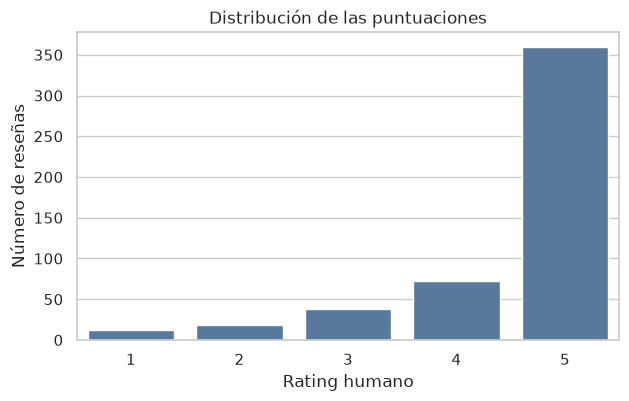

In [3]:
rating_counts = reviews["rating"].value_counts().sort_index()
rating_summary = pd.DataFrame({
    "reviews": rating_counts,
    "percentage": (rating_counts / len(reviews) * 100).round(1),
})

print(f"Puntuación media: {reviews['rating'].mean():.2f} / 5")
print(rating_summary)

plt.figure(figsize=(7, 4))
sns.countplot(data=reviews, x="rating", color="#4C78A8")
plt.title("Distribución de las puntuaciones")
plt.xlabel("Rating humano")
plt.ylabel("Número de reseñas")
plt.show()

## 3. Longitud de las reseñas

Medimos el número de palabras para comprobar si los textos tienen suficiente contexto y si existen valores extremos.

count    500.00
mean      29.10
std        4.82
min       14.00
25%       26.00
50%       29.00
75%       32.00
max       42.00
Name: word_count, dtype: float64


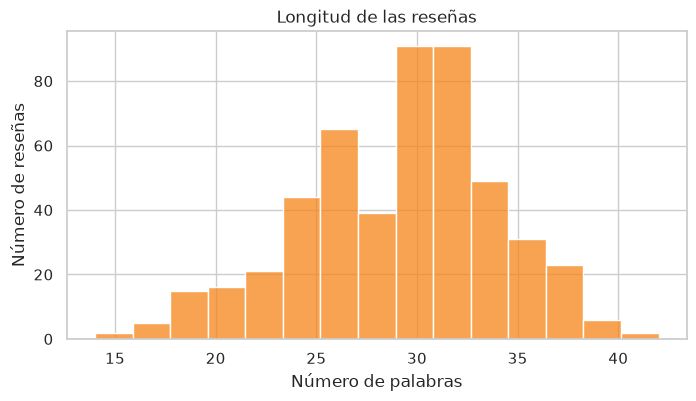

In [4]:
reviews["word_count"] = reviews["review_text"].str.split().str.len()

print(reviews["word_count"].describe().round(2))

plt.figure(figsize=(8, 4))
sns.histplot(data=reviews, x="word_count", bins=15, color="#F58518")
plt.title("Longitud de las reseñas")
plt.xlabel("Número de palabras")
plt.ylabel("Número de reseñas")
plt.show()

## 4. Muestra de textos

Finalmente, revisamos ejemplos reales para entender el tono y el tipo de lenguaje utilizado por los clientes.

In [5]:
print(reviews[["review_id", "rating", "review_text"]].sample(5, random_state=42).to_string(index=False))

 review_id  rating                                                                                                                                                                                            review_text
       362       3                                                                      Stopped by Harbor House Café for the first time. The coffee was okay. Average service, no complaints. It's fine for a quick stop.
        74       5                                        Stopped by Harbor House Café for the first time. The place has such a cozy, welcoming vibe. Every dish was bursting with flavor. Five stars without hesitation.
       375       5 Grabbed a quick coffee at Harbor House Café this morning. Service was fast and friendly. The place has such a cozy, welcoming vibe. Reasonably priced for the quality. Already planning my next visit.
       156       4  Grabbed a quick coffee at Harbor House Café this morning. The coffee was rich and perfectly brewed. The staf

## 5. Insights accionables

Los principales hallazgos de esta exploración son:

- El dataset contiene 500 reseñas y tres columnas esperadas: identificador, puntuación y texto.
- La puntuación media es exactamente 4.5 estrellas. Hay un claro predominio de puntuaciones de 5 estrellas: 360 de 500 reseñas (72%).
- También existe una minoría relevante de reseñas de 1 a 3 estrellas (68 reseñas, 13.6%), que conviene comparar con el sentimiento escrito.
- Los textos tienen una longitud suficiente para aportar contexto: una mediana de 29 palabras, con valores entre 14 y 42 palabras.
- Las reseñas mezclan valoraciones generales con detalles sobre café, comida, servicio y ambiente. Esto hace especialmente importante comprobar si una queja puntual cambia la predicción del modelo.

## 6. Propuesta de limpieza

No se necesita una limpieza agresiva. No hay valores ausentes, filas duplicadas ni identificadores repetidos, y las columnas tienen los tipos esperados.

Conservaremos el texto completo porque palabras de contexto como `pero`, `aunque` o `no` pueden cambiar el significado de una reseña. No modificaremos el texto antes de aplicar el modelo.

Esta etapa termina con la exploración y la propuesta de limpieza. El modelado y la comparación entre estrellas y sentimiento se realizarán después, en las siguientes secciones del proyecto.

## 7. Plan de acción y justificación del modelo

La exploración confirma que tenemos 500 textos completos, sin valores ausentes ni duplicados, y con una distribución de ratings muy concentrada en 4 y 5 estrellas. Por ello, el siguiente paso será comparar la puntuación humana con el sentimiento que se desprende del texto.

### Plan

1. Cargar una única vez el modelo preentrenado de Hugging Face.
2. Procesar las 500 reseñas y guardar la predicción de estrellas para cada una.
3. Convertir la predicción a una banda de sentimiento:
   - 1–2 estrellas: negativo.
   - 3 estrellas: neutral.
   - 4–5 estrellas: positivo.
4. Comparar las bandas predichas con el rating humano y con la media de 4.5 estrellas.
5. Revisar manualmente una muestra de 15–20 reseñas, prestando especial atención a los desacuerdos.

### Modelo elegido

Utilizaremos `nlptown/bert-base-multilingual-uncased-sentiment`. Es adecuado como primera aproximación porque ya está ajustado para interpretar reseñas en varios idiomas y devuelve una valoración de 1 a 5 estrellas.

No entrenaremos un modelo desde cero. La integración se hará mediante `pipeline()` y el modelo se cargará una sola vez, antes de la inferencia. En la fase de implementación fijaremos explícitamente el identificador y la revisión del modelo, además de las versiones de las dependencias, para que otra ejecución no dependa de cambios posteriores en Hugging Face.

### Limitación que debemos comprobar

El modelo fue entrenado principalmente con reseñas de productos, mientras que nuestro dataset contiene reseñas de servicios. Una queja sobre la espera, el personal o el ambiente puede aparecer junto a una valoración general positiva. Por ese desajuste esperamos posibles falsos negativos: reseñas con 4 o 5 estrellas que el modelo clasifique como negativas.

Por ese motivo no interpretaremos la predicción como una verdad absoluta. La utilizaremos como una segunda señal, la compararemos con las estrellas y revisaremos ejemplos concretos antes de extraer conclusiones para la account manager.

Esta sección define el plan. La inferencia y sus resultados se añadirán en el siguiente paso.

## 8. Inferencia de sentimiento

Ahora aplicamos el modelo fijado a las 500 reseñas. El pipeline se crea una sola vez y después se reutiliza para todas las reseñas.

In [6]:
from transformers import pipeline

MODEL_NAME = "nlptown/bert-base-multilingual-uncased-sentiment"
MODEL_REVISION = "8f6f4e3a8f70be4b65d3a4a8762b6d781cda240d"

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=MODEL_NAME,
    revision=MODEL_REVISION,
)

predictions = sentiment_pipeline(
    reviews["review_text"].tolist(),
    truncation=True,
    batch_size=16,
)

reviews["predicted_rating"] = [int(prediction["label"].split()[0]) for prediction in predictions]

sentiment_map = {
    1: "negative",
    2: "negative",
    3: "neutral",
    4: "positive",
    5: "positive",
}
reviews["sentiment"] = reviews["predicted_rating"].map(sentiment_map)

reviews[["review_id", "rating", "predicted_rating", "sentiment", "review_text"]].head()

Device set to use cpu


,review_id,rating,predicted_rating,sentiment,review_text
0,1,5,5,positive,Visited Harbor House Café last weekend. Great ...
1,2,5,5,positive,Tried Harbor House Café after seeing it recomm...
2,3,5,5,positive,Tried Harbor House Café after seeing it recomm...
3,4,5,5,positive,Visited Harbor House Café last weekend. The st...
4,5,5,5,positive,Grabbed a quick coffee at Harbor House Café th...


## 9. Distribución del sentimiento predicho

Convertimos las predicciones de estrellas en porcentajes sencillos para la account manager y las comparamos con la distribución humana.

           reviews  percentage
sentiment                     
positive       412        82.4
neutral         41         8.2
negative        47         9.4

Comparación con los ratings humanos:
sentiment  negative  neutral  positive
rating                                
1             1.000    0.000     0.000
2             0.889    0.111     0.000
3             0.079    0.921     0.000
4             0.014    0.042     0.944
5             0.042    0.003     0.956


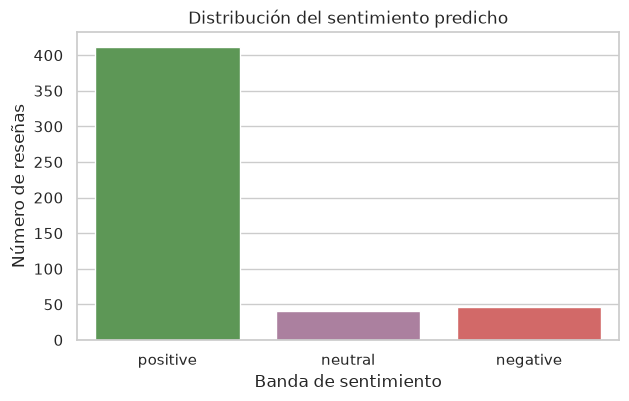

In [7]:
sentiment_summary = (
    reviews["sentiment"]
    .value_counts()
    .reindex(["positive", "neutral", "negative"], fill_value=0)
    .rename_axis("sentiment")
    .to_frame("reviews")
)
sentiment_summary["percentage"] = (
    sentiment_summary["reviews"] / len(reviews) * 100
).round(1)

print(sentiment_summary)
print("\nComparación con los ratings humanos:")
print(pd.crosstab(reviews["rating"], reviews["sentiment"], normalize="index").round(3))

plt.figure(figsize=(7, 4))
sns.countplot(
    data=reviews,
    x="sentiment",
    order=["positive", "neutral", "negative"],
    palette=["#54A24B", "#B279A2", "#E45756"],
    hue="sentiment",
    legend=False,
)
plt.title("Distribución del sentimiento predicho")
plt.xlabel("Banda de sentimiento")
plt.ylabel("Número de reseñas")
plt.show()

## 10. Comparación con la puntuación media de 4.5 estrellas

El negocio tiene una media humana de 4.5 estrellas. El modelo clasifica el 82.4% de los textos como positivos, el 8.2% como neutrales y el 9.4% como negativos.

La señal general es coherente con una valoración alta: la categoría positiva es claramente mayoritaria. Sin embargo, el texto muestra una proporción negativa superior a la que sugeriría mirar únicamente la media, por lo que puede descubrir problemas concretos aunque la puntuación global siga siendo buena.

La tabla siguiente cruza las estrellas humanas con las bandas predichas. Así podemos distinguir coincidencias de desacuerdos.

In [8]:
comparison_table = pd.crosstab(reviews["rating"], reviews["sentiment"])
comparison_table = comparison_table.reindex(
    index=[1, 2, 3, 4, 5],
    columns=["negative", "neutral", "positive"],
    fill_value=0,
)
comparison_table

sentiment,negative,neutral,positive
rating,,,
1,12,0,0
2,16,2,0
3,3,35,0
4,1,3,68
5,15,1,344


## 11. Falsos negativos y revisión de casos

Buscamos especialmente reseñas con 4 o 5 estrellas humanas que el modelo clasifica como negativas. Son casos importantes porque muestran dónde el modelo puede ser demasiado pesimista.

In [9]:
false_negatives = reviews[
    (reviews["rating"] >= 4) & (reviews["predicted_rating"] <= 2)
].copy()

print(f"Falsos negativos identificados: {len(false_negatives)}")
false_negatives[["review_id", "rating", "predicted_rating", "sentiment", "review_text"]]

Falsos negativos identificados: 16


,review_id,rating,predicted_rating,sentiment,review_text
13,14,4,1,negative,Tried Harbor House Café after seeing it recomm...
14,15,5,1,negative,Every dish was bursting with flavor. The place...
72,73,5,1,negative,Stopped by Harbor House Café for the first tim...
86,87,5,1,negative,Tried Harbor House Café after seeing it recomm...
137,138,5,2,negative,Tried Harbor House Café after seeing it recomm...
199,200,5,2,negative,Stopped by Harbor House Café for the first tim...
203,204,5,1,negative,Came to Harbor House Café for a birthday brunc...
253,254,5,1,negative,Stopped by Harbor House Café for the first tim...
269,270,5,1,negative,Stopped by Harbor House Café for the first tim...
321,322,5,1,negative,Every dish was bursting with flavor. The staff...


Los 16 falsos negativos encontrados tienen un patrón llamativo: la mayoría son reseñas claramente positivas, con expresiones como “bursting with flavor”, “will definitely be back” o “already planning my next visit”. Esto sugiere que el modelo puede estar sobreestimando la negatividad en este dataset de servicios.

Una hipótesis es que el modelo de reseñas de productos no está calibrado para este tipo de textos. También conviene comprobar si estas predicciones extremas se deben al vocabulario, al contexto del dominio o a una diferencia entre la puntuación humana y el estilo de redacción.

## 12. Muestra manual de 20 reseñas

Para no depender únicamente de métricas agregadas, revisamos manualmente una muestra reproducible de 20 reseñas. La selección incluye distintos ratings humanos y desacuerdos entre la puntuación humana y el modelo.

In [10]:
manual_sample = reviews.sample(20, random_state=2026).sort_values("review_id")
manual_sample[["review_id", "rating", "predicted_rating", "sentiment", "review_text"]]

,review_id,rating,predicted_rating,sentiment,review_text
44,45,4,4,positive,Came to Harbor House Café for a birthday brunc...
84,85,5,4,positive,Tried Harbor House Café after seeing it recomm...
119,120,5,5,positive,Stopped by Harbor House Café for the first tim...
133,134,5,5,positive,Came to Harbor House Café for a birthday brunc...
138,139,5,5,positive,Tried Harbor House Café after seeing it recomm...
154,155,3,3,neutral,Tried Harbor House Café after seeing it recomm...
156,157,5,5,positive,Regular customer at Harbor House Café here. Th...
165,166,4,5,positive,Tried Harbor House Café after seeing it recomm...
183,184,5,5,positive,Tried Harbor House Café after seeing it recomm...
191,192,2,3,neutral,Regular customer at Harbor House Café here. Th...


### Notas de la revisión manual

- En general, las reseñas de 4 y 5 estrellas con predicción positiva son coherentes: expresan satisfacción con la comida, el café, el personal o el ambiente.
- Las reseñas de 1 y 2 estrellas se clasifican mayoritariamente como negativas, por lo que el modelo detecta correctamente buena parte de la insatisfacción explícita.
- Las reseñas de 3 estrellas suelen aparecer como neutrales, especialmente cuando el texto usa expresiones como “okay”, “average” o “fine”.
- Los desacuerdos más llamativos son los falsos negativos: varios textos con lenguaje inequívocamente positivo reciben 1 o 2 estrellas predichas.
- La revisión manual confirma que la banda predicha es útil como señal agregada, pero no debe sustituir la lectura del texto ni el rating humano.

## 13. Conclusiones provisionales

- La media humana de 4.5 estrellas y el 82.4% de sentimiento positivo muestran una percepción global favorable.
- El 9.4% de sentimiento negativo indica que el texto puede revelar problemas que no se ven al observar solamente la media.
- Se identificaron 16 casos en los que una reseña con 4 o 5 estrellas fue clasificada como negativa. La mayoría son falsos negativos claros al leer el texto.
- El modelo es una primera señal útil para resumir las 500 reseñas, pero su desajuste con el dominio de servicios limita la confianza en sus predicciones individuales.
- Para la account manager, el mensaje principal es que la valoración general sigue siendo positiva, pero conviene investigar los temas de servicio que aparecen dentro de reseñas con puntuaciones altas.

En el siguiente paso trasladaremos la lógica de inferencia a `src/app.py` y generaremos `data/processed/reviews_with_sentiment.csv` para uso en producción.